In [64]:
# Dependency imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.ensemble import GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score

In [65]:
# Load the dataset
df = pd.read_csv('Data\\construction_dataset.csv')

In [66]:
# Data Cleaning
df.dropna(inplace=True)
for row in df.itertuples():
    match row.Risk_Level:
        case 'Low':
            df.at[row.Index, 'Risk_Level'] = 1
        case 'Medium':
            df.at[row.Index, 'Risk_Level'] = 2
        case 'High':
            df.at[row.Index, 'Risk_Level'] = 3

df.drop(columns=['Task_ID'], inplace=True, axis=1)

In [30]:
df.isnull().sum()

Task_Duration_Days           0
Labor_Required               0
Equipment_Units              0
Material_Cost_USD            0
Start_Constraint             0
Risk_Level                   0
Resource_Constraint_Score    0
Site_Constraint_Score        0
Dependency_Count             0
dtype: int64

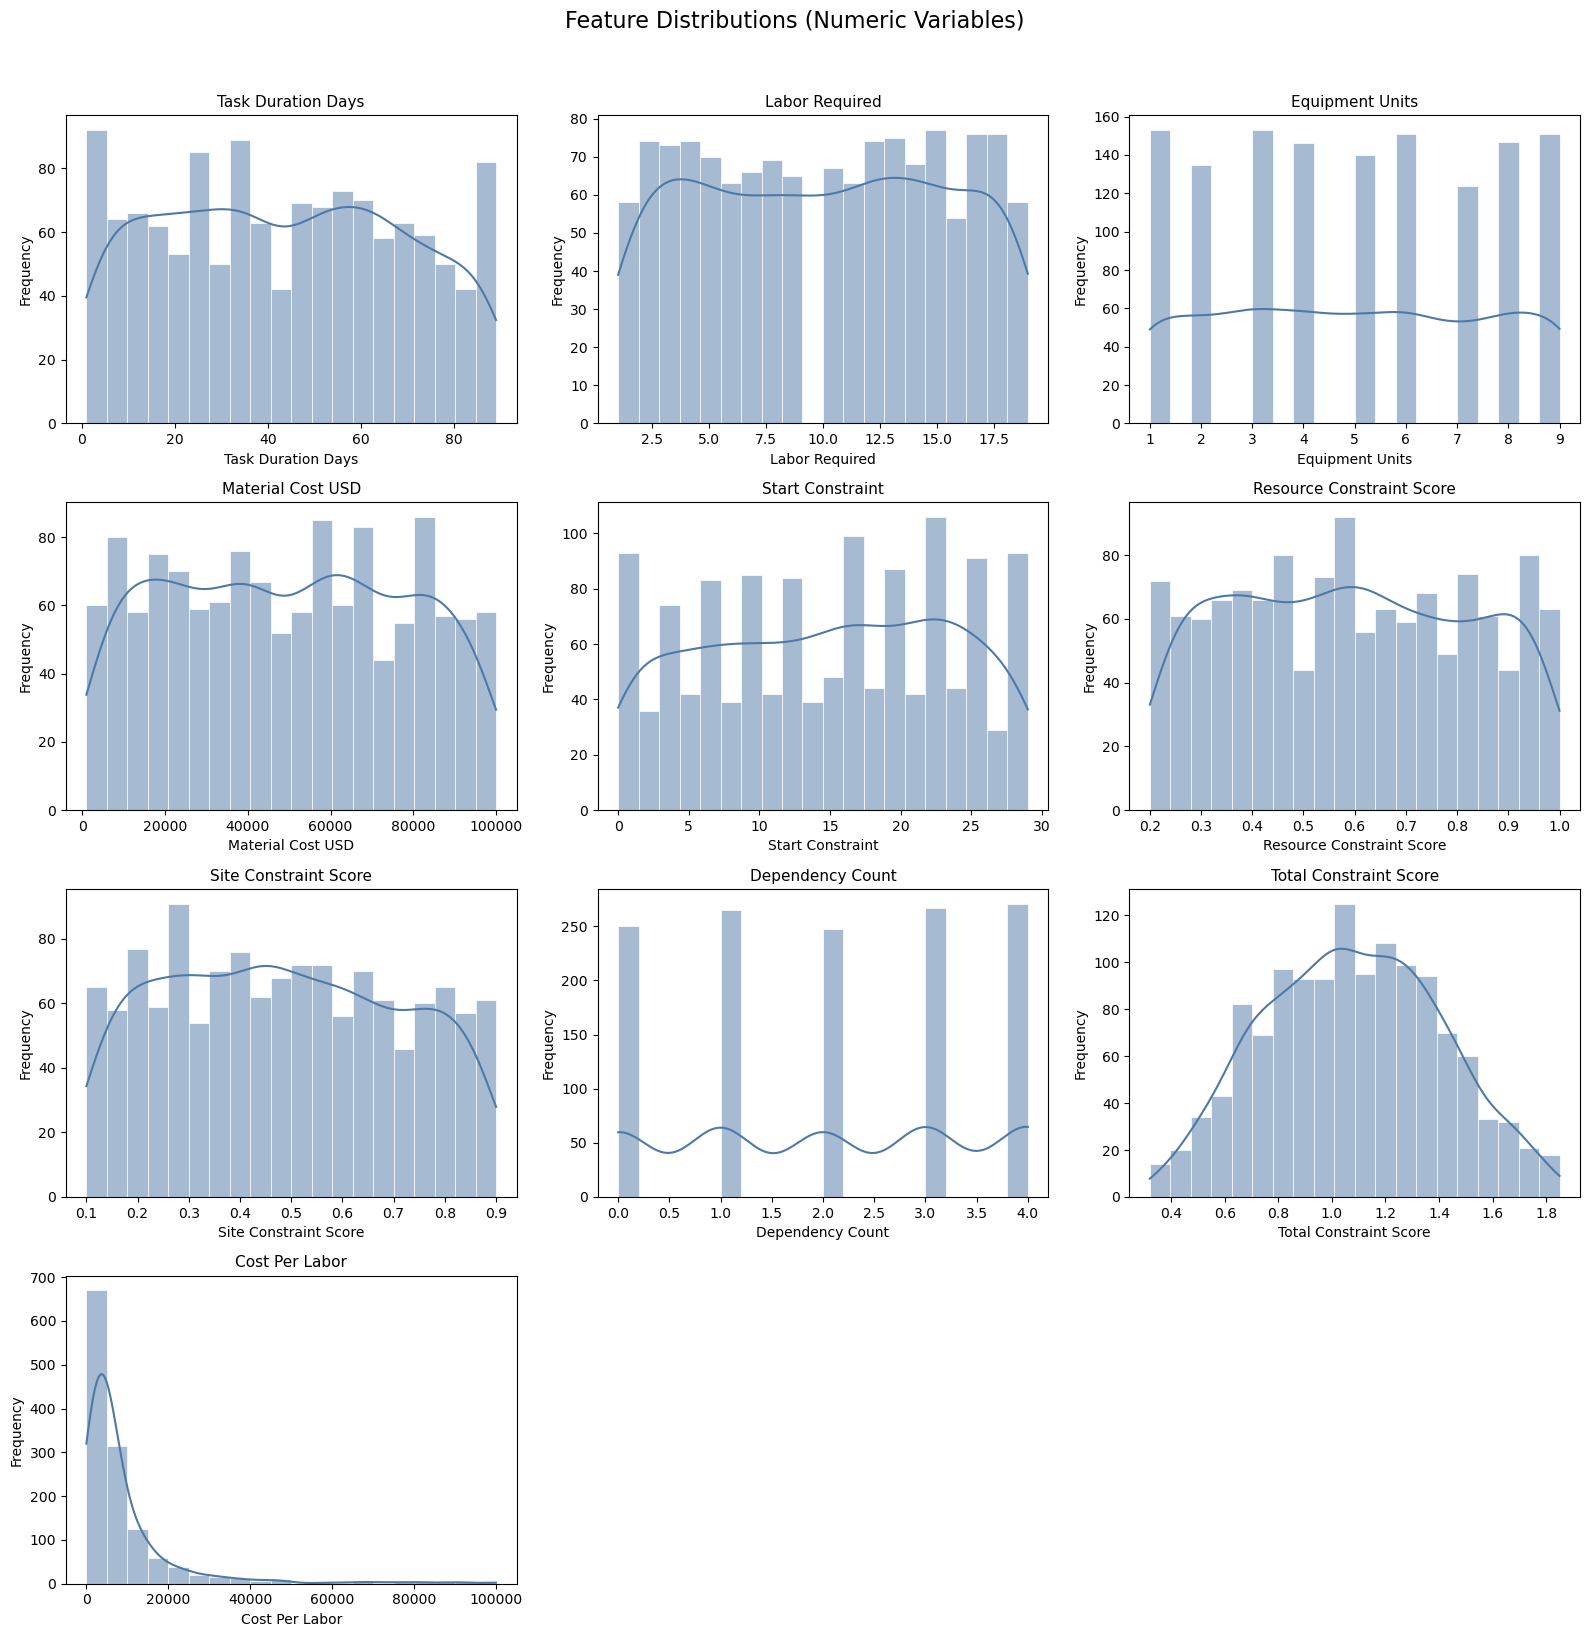

In [84]:
numeric_cols = df.select_dtypes(include=[np.number]).columns
n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = np.array(axes).reshape(n_rows, n_cols)

for i, col in enumerate(numeric_cols):
    ax = axes.flat[i]
    pretty_col = col.replace('_', ' ')
    sns.histplot(
        df[col],
        bins=20,
        kde=True,
        ax=ax,
        color='#4e79a7',
        edgecolor='white',
        linewidth=0.5
    )
    ax.set_title(pretty_col, fontsize=11)
    ax.set_xlabel(pretty_col)
    ax.set_ylabel('Frequency')

# Remove any unused subplot axes for cleaner layout.
for j in range(len(numeric_cols), n_rows * n_cols):
    fig.delaxes(axes.flat[j])

fig.suptitle('Feature Distributions (Numeric Variables)', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

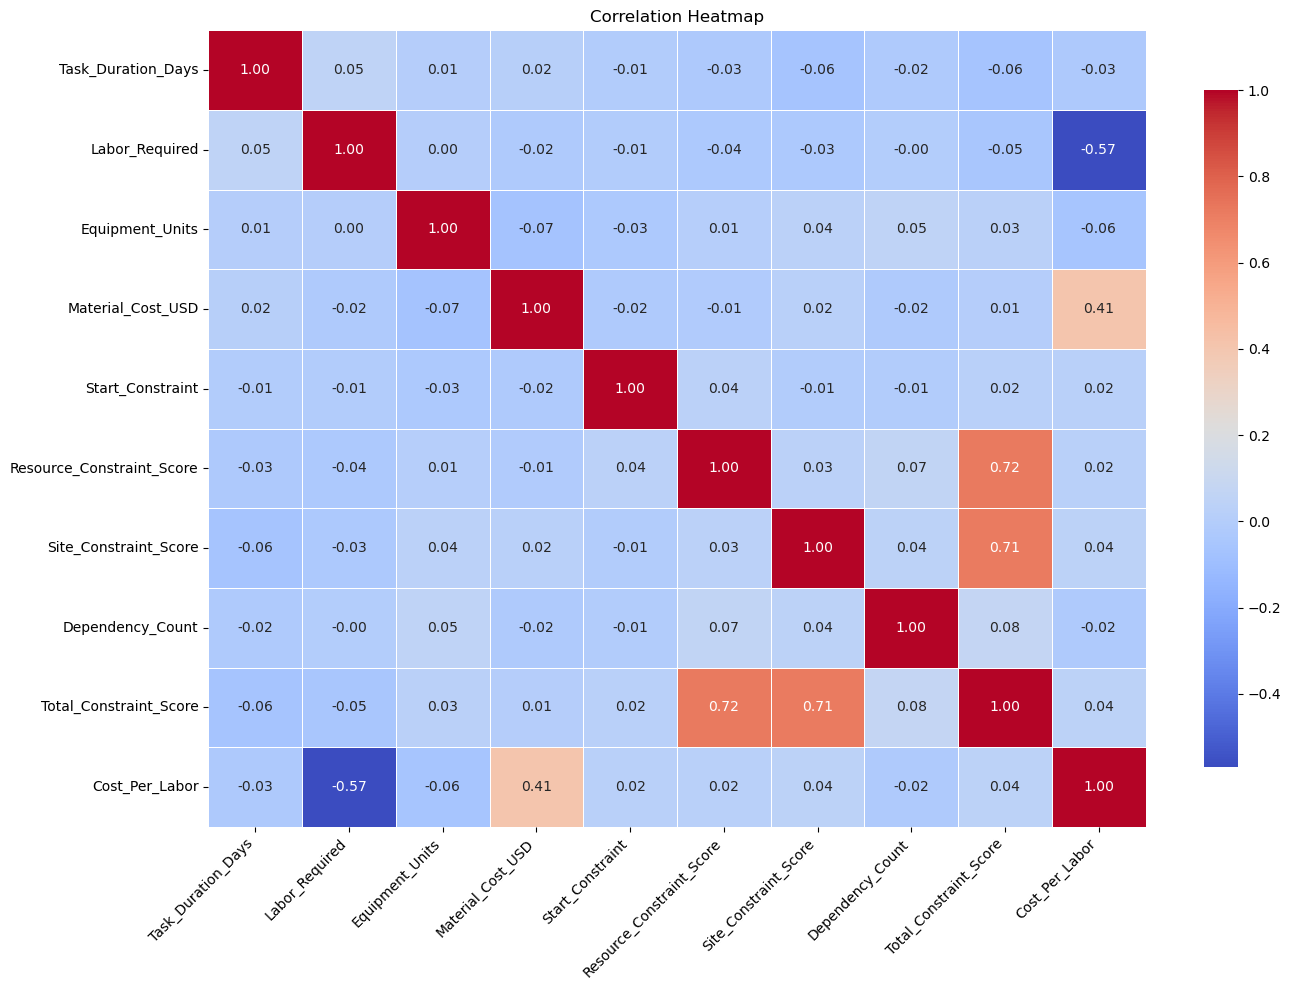

In [82]:
corr_matrix = df.corr(numeric_only=True)
plt.figure(figsize=(14, 10))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    annot_kws={'size': 10},
    cbar_kws={'shrink': 0.85}
 )
plt.title('Correlation Heatmap')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [67]:
df['Total_Constraint_Score'] = df['Resource_Constraint_Score'] + df['Site_Constraint_Score']
df['Cost_Per_Labor'] = df['Material_Cost_USD'] / df['Labor_Required']+1
df['Weighted_Risk'] = df['Total_Constraint_Score'] * df['Risk_Level']

In [34]:
df.head()


,Task_Duration_Days,Labor_Required,Equipment_Units,Material_Cost_USD,Start_Constraint,Risk_Level,Resource_Constraint_Score,Site_Constraint_Score,Dependency_Count,Total_Constraint_Score,Cost_Per_Labor,Weighted_Risk
0,52,14,6,16789.73,0,2,0.41,0.59,4,1.00,1200.266429,2.0
1,15,2,2,16885.80,5,1,0.75,0.17,3,0.92,8443.900000,0.92
2,72,11,1,7978.70,22,1,0.96,0.41,1,1.37,726.336364,1.37
3,61,1,5,19379.02,18,1,0.41,0.67,4,1.08,19380.020000,1.08
4,21,19,5,66757.72,22,1,0.85,0.63,3,1.48,3514.564211,1.48


In [68]:
x = df[['Material_Cost_USD', 'Labor_Required', 'Equipment_Units', 'Start_Constraint', 'Risk_Level', 'Resource_Constraint_Score', 'Site_Constraint_Score', 'Dependency_Count', 'Total_Constraint_Score', 'Cost_Per_Labor', 'Weighted_Risk']]

y = df['Task_Duration_Days']

In [69]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=13)

In [70]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [71]:
lr = LinearRegression()
lr.fit(x_train_scaled, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [72]:
rf = RandomForestRegressor(n_estimators=100, random_state=13)
rf.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [73]:
gb = GradientBoostingRegressor(n_estimators=100, random_state=13)

gb.fit(x_train, y_train)

,"loss loss: {'squared_error', 'absolute_error', 'huber', 'quantile'}, default='squared_error'Loss function to be optimized. 'squared_error' refers to the squarederror for regression. 'absolute_error' refers to the absolute error ofregression and is a robust loss function. 'huber' is acombination of the two. 'quantile' allows quantile regression (use`alpha` to specify the quantile).See:ref:`sphx_glr_auto_examples_ensemble_plot_gradient_boosting_quantile.py`for an example that demonstrates quantile regression for creatingprediction intervals with `loss='quantile'`.",'squared_error'
,"learning_rate learning_rate: float, default=0.1Learning rate shrinks the contribution of each tree by `learning_rate`.There is a trade-off between learning_rate and n_estimators.Values must be in the range `[0.0, inf)`.",0.1
,"n_estimators n_estimators: int, default=100The number of boosting stages to perform. Gradient boostingis fairly robust to over-fitting so a large number usuallyresults in better performance.Values must be in the range `[1, inf)`.",100
,"subsample subsample: float, default=1.0The fraction of samples to be used for fitting the individual baselearners. If smaller than 1.0 this results in Stochastic GradientBoosting. `subsample` interacts with the parameter `n_estimators`.Choosing `subsample < 1.0` leads to a reduction of varianceand an increase in bias.Values must be in the range `(0.0, 1.0]`.",1.0
,"criterion criterion: {'friedman_mse', 'squared_error'}, default='friedman_mse'The function to measure the quality of a split. Supported criteria are""friedman_mse"" for the mean squared error with improvement score byFriedman, ""squared_error"" for mean squared error. The default value of""friedman_mse"" is generally the best as it can provide a betterapproximation in some cases... versionadded:: 0.18",'friedman_mse'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, values must be in the range `[2, inf)`.- If float, values must be in the range `(0.0, 1.0]` and `min_samples_split` will be `ceil(min_samples_split * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, values must be in the range `[1, inf)`.- If float, values must be in the range `(0.0, 1.0)` and `min_samples_leaf` will be `ceil(min_samples_leaf * n_samples)`... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.Values must be in the range `[0.0, 0.5]`.",0.0
,"max_depth max_depth: int or None, default=3Maximum depth of the individual regression estimators. The maximumdepth limits the number of nodes in the tree. Tune this parameterfor best performance; the best value depends on the interactionof the input variables. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.If int, values must be in the range `[1, inf)`.",3
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.Values must be in the range `[0.0, inf)`.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft 

In [74]:
models = {
    'Linear Regression': lr,
    'Random Forest': rf,
    'Gradient Boosting': gb
}

cv_scores = {}

for name, model in models.items():
    scores = cross_val_score(
        model, x, y, cv=5, scoring='neg_mean_absolute_error'
    )
    cv_scores[name] = -scores.mean()

print(f"List of CV Scores: {cv_scores}")

List of CV Scores: {'Linear Regression': 22.368655044721958, 'Random Forest': 22.290984615384616, 'Gradient Boosting': 22.720267051553563}


In [75]:
rf_preds = rf.predict(x_test)

mae = mean_absolute_error(y_test, rf_preds)
rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
r2 = r2_score(y_test, rf_preds)

print("Random Forest Performance on Test Set:")
print("-----------------------------")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R²: {r2}")

Random Forest Performance on Test Set:
-----------------------------
MAE: 22.44726923076923
RMSE: 26.33279246198841
R²: -0.05965248713924387


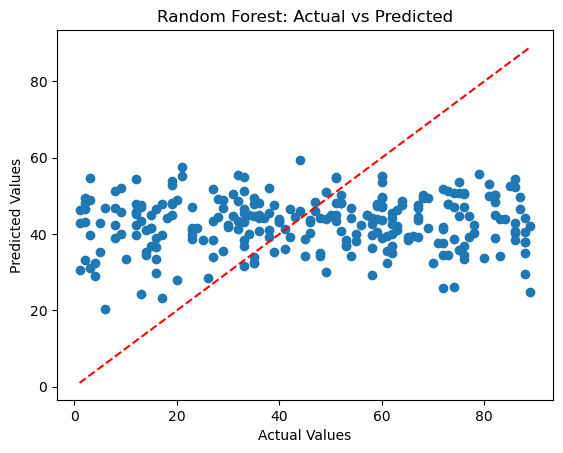

In [52]:
plt.scatter(y_test, rf_preds)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, 'Material_Cost_USD'),
  Text(1, 0, 'Labor_Required'),
  Text(2, 0, 'Equipment_Units'),
  Text(3, 0, 'Start_Constraint'),
  Text(4, 0, 'Risk_Level'),
  Text(5, 0, 'Resource_Constraint_Score'),
  Text(6, 0, 'Site_Constraint_Score'),
  Text(7, 0, 'Dependency_Count'),
  Text(8, 0, 'Total_Constraint_Score'),
  Text(9, 0, 'Cost_Per_Labor'),
  Text(10, 0, 'Weighted_Risk')])

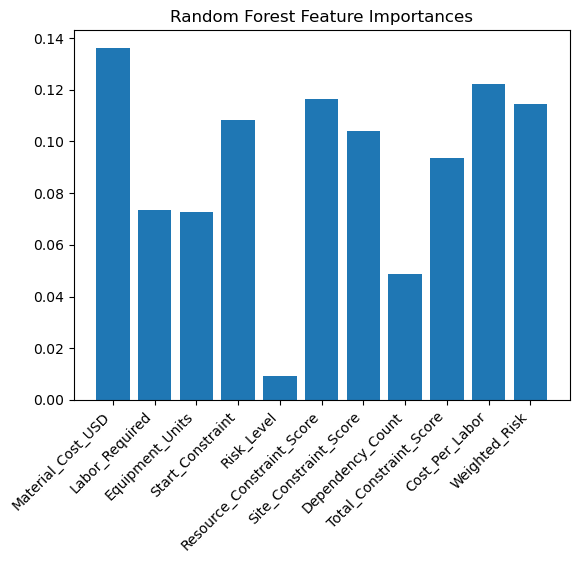

In [44]:
rf_importance = rf.feature_importances_

plt.bar(x.columns, rf_importance)
plt.title("Random Forest Feature Importances")
plt.xticks(rotation=45, ha='right')

Text(0.5, 1.0, 'Random Forest Residuals')

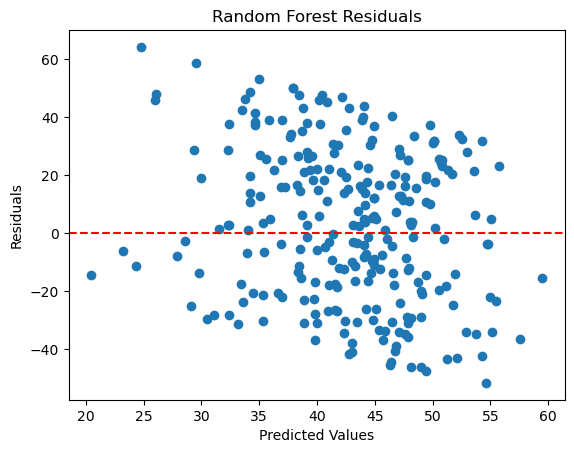

In [57]:
rf_residuals = y_test - rf_preds
plt.scatter(rf_preds, rf_residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Random Forest Residuals")

Text(0, 0.5, 'Frequency')

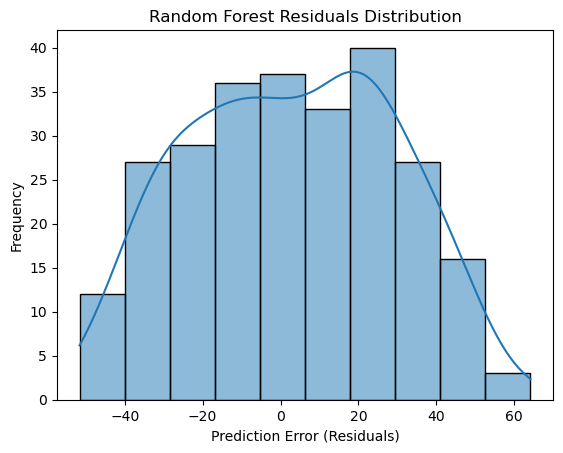

In [61]:
sns.histplot(rf_residuals, kde=True)
plt.title("Random Forest Residuals Distribution")
plt.xlabel("Prediction Error (Residuals)")
plt.ylabel("Frequency")

In [76]:
lr_preds = lr.predict(x_test_scaled)

mae = mean_absolute_error(y_test, lr_preds)
rmse = np.sqrt(mean_squared_error(y_test, lr_preds))
r2 = r2_score(y_test, lr_preds)

print("Linear Regression Performance on Test Set:")
print("-----------------------------")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R²: {r2}")

Linear Regression Performance on Test Set:
-----------------------------
MAE: 22.66064933407438
RMSE: 26.18173555772911
R²: -0.04753005739572291


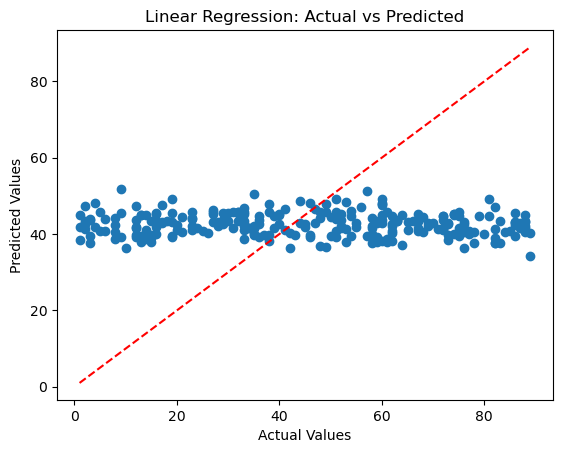

In [53]:
plt.scatter(y_test, lr_preds)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

Text(0.5, 1.0, 'Linear Regression Coefficients')

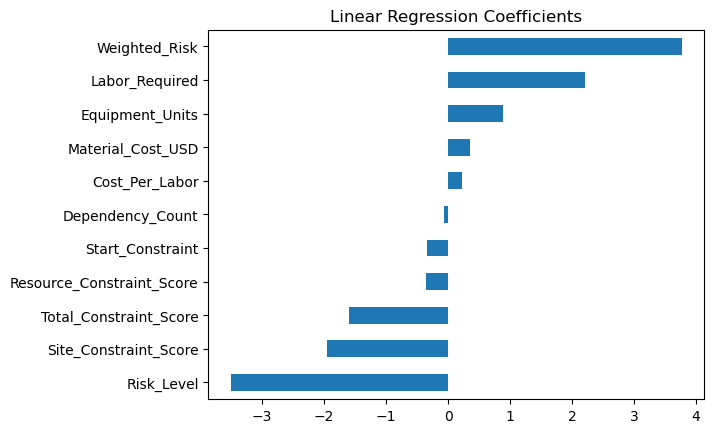

In [56]:
coefficients = pd.Series(lr.coef_, index=x.columns)
coefficients.sort_values().plot(kind='barh')
plt.title("Linear Regression Coefficients")

Text(0.5, 1.0, 'Linear Regression Residuals')

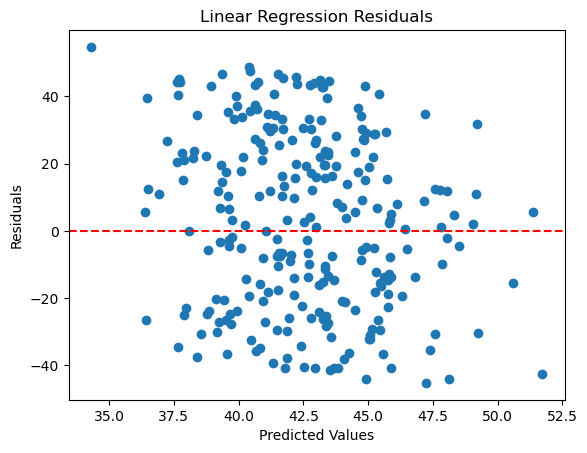

In [58]:
lr_residuals = y_test - lr_preds
plt.scatter(lr_preds, lr_residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Linear Regression Residuals")

Text(0, 0.5, 'Frequency')

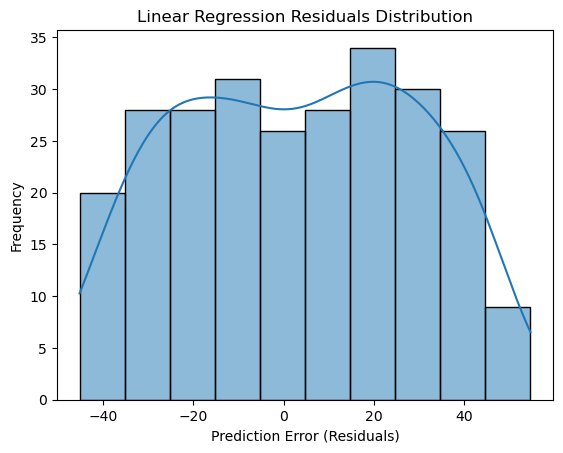

In [62]:
sns.histplot(lr_residuals, kde=True)
plt.title("Linear Regression Residuals Distribution")
plt.xlabel("Prediction Error (Residuals)")
plt.ylabel("Frequency")

In [77]:
gb_preds = gb.predict(x_test)

mae = mean_absolute_error(y_test, gb_preds)
rmse = np.sqrt(mean_squared_error(y_test, gb_preds))
r2 = r2_score(y_test, gb_preds)

print("Gradient Boosting Performance on Test Set:")
print("-----------------------------")
print(f"MAE: {mae}")
print(f"RMSE: {rmse}")
print(f"R²: {r2}")

Gradient Boosting Performance on Test Set:
-----------------------------
MAE: 22.579274176736245
RMSE: 26.661407399177502
R²: -0.08626496228585445


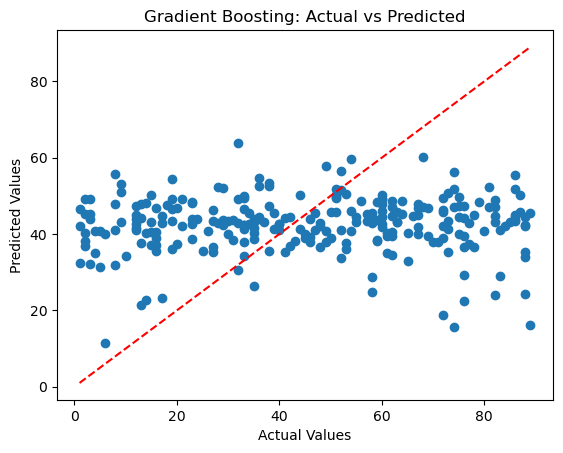

In [54]:
plt.scatter(y_test, gb_preds)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Gradient Boosting: Actual vs Predicted")
plt.show()

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10],
 [Text(0, 0, 'Material_Cost_USD'),
  Text(1, 0, 'Labor_Required'),
  Text(2, 0, 'Equipment_Units'),
  Text(3, 0, 'Start_Constraint'),
  Text(4, 0, 'Risk_Level'),
  Text(5, 0, 'Resource_Constraint_Score'),
  Text(6, 0, 'Site_Constraint_Score'),
  Text(7, 0, 'Dependency_Count'),
  Text(8, 0, 'Total_Constraint_Score'),
  Text(9, 0, 'Cost_Per_Labor'),
  Text(10, 0, 'Weighted_Risk')])

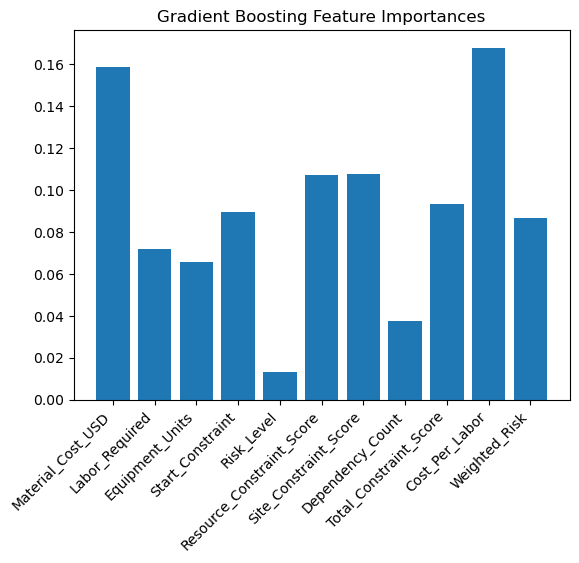

In [51]:
gb_importance = gb.feature_importances_

plt.bar(x.columns, gb_importance)
plt.title("Gradient Boosting Feature Importances")
plt.xticks(rotation=45, ha='right')

Text(0.5, 1.0, 'Gradient Boosting Residuals')

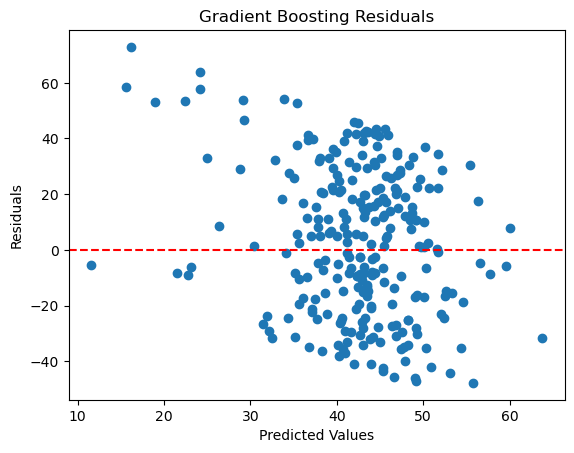

In [59]:
gb_residuals = y_test - gb_preds
plt.scatter(gb_preds, gb_residuals)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Gradient Boosting Residuals")

Text(0, 0.5, 'Frequency')

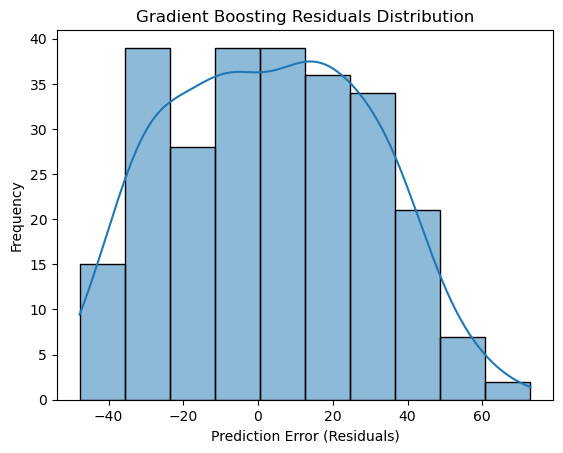

In [63]:
sns.histplot(gb_residuals, kde=True)
plt.title("Gradient Boosting Residuals Distribution")
plt.xlabel("Prediction Error (Residuals)")
plt.ylabel("Frequency")

## Baseline Benchmark and Model Comparison
Compare all trained models against a naive baseline that predicts the training-set mean. A useful model should clearly beat this baseline on MAE/RMSE and have positive R².

Model Comparison (lower MAE/RMSE is better, higher R2 is better):


,MAE,RMSE,R2
Baseline (Mean Predictor),22.3717,25.7389,-0.0124
Random Forest,22.4473,26.3328,-0.0597
Gradient Boosting,22.5793,26.6614,-0.0863
Linear Regression,22.6606,26.1817,-0.0475


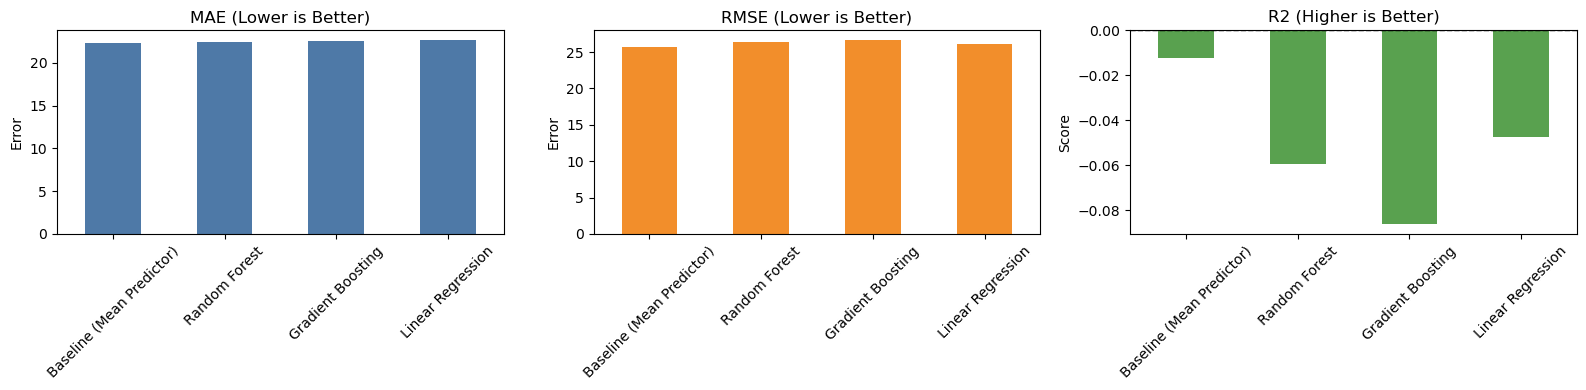

In [78]:
from sklearn.dummy import DummyRegressor

# Baseline model: always predicts the training-set mean.
dummy = DummyRegressor(strategy='mean')
dummy.fit(x_train, y_train)
baseline_preds = dummy.predict(x_test)

# Fresh predictions for consistent comparison.
lr_preds_cmp = lr.predict(x_test_scaled)
rf_preds_cmp = rf.predict(x_test)
gb_preds_cmp = gb.predict(x_test)


def get_metrics(y_true, y_pred):
    return {
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)),
        'R2': r2_score(y_true, y_pred)
    }

results = {
    'Baseline (Mean Predictor)': get_metrics(y_test, baseline_preds),
    'Linear Regression': get_metrics(y_test, lr_preds_cmp),
    'Random Forest': get_metrics(y_test, rf_preds_cmp),
    'Gradient Boosting': get_metrics(y_test, gb_preds_cmp)
}

comparison_df = pd.DataFrame(results).T
comparison_df = comparison_df.sort_values(by='MAE')

print('Model Comparison (lower MAE/RMSE is better, higher R2 is better):')
display(comparison_df.round(4))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
comparison_df['MAE'].plot(kind='bar', ax=axes[0], color='#4e79a7')
axes[0].set_title('MAE (Lower is Better)')
axes[0].set_ylabel('Error')
axes[0].tick_params(axis='x', rotation=45)

comparison_df['RMSE'].plot(kind='bar', ax=axes[1], color='#f28e2b')
axes[1].set_title('RMSE (Lower is Better)')
axes[1].set_ylabel('Error')
axes[1].tick_params(axis='x', rotation=45)

comparison_df['R2'].plot(kind='bar', ax=axes[2], color='#59a14f')
axes[2].set_title('R2 (Higher is Better)')
axes[2].set_ylabel('Score')
axes[2].axhline(0, color='black', linestyle='--', linewidth=1)
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [79]:
df.corr()['Task_Duration_Days'].sort_values(ascending=False)

Task_Duration_Days           1.000000
Labor_Required               0.051290
Material_Cost_USD            0.015340
Equipment_Units              0.006068
Risk_Level                   0.003599
Start_Constraint            -0.009244
Dependency_Count            -0.021334
Cost_Per_Labor              -0.025867
Weighted_Risk               -0.027221
Resource_Constraint_Score   -0.027677
Site_Constraint_Score       -0.062465
Total_Constraint_Score      -0.062511
Name: Task_Duration_Days, dtype: float64